# Введение: Почему именно PyTorch?

`PyTorch` — это не просто библиотека для машинного обучения. Это гибкий инструмент, который позволяет:

> Работать с тензорами так же естественно, как с массивами NumPy, но с возможностью ускорения на GPU  
> Автоматически вычислять градиенты благодаря системе autograd  
> Собирать нейросети как конструктор из модулей nn.Module  
> Отлаживать код в интерактивном режиме (в отличие от статических графов)  

В этой домашке будет путь от простых тензорных операций до полноценного пайплайна обучения нейросети — всё на чистом PyTorch без «костылей» в виде циклов и списков.

_Если вы хотите сразу на что-то опираться, то можно смотреть сюда:_

* Официальная документация: [pytorch.org/docs](https://docs.pytorch.org/docs/stable/index.html)  
* Интерактивный туториал: [PyTorch Tutorial](https://docs.pytorch.org/tutorials/beginner/pytorch_with_examples.html?spm=a2ty_o01.29997173.0.0.478a5171OnczYJ)
***
* Очень хороший гайд по markdown: [markdown-shpargalka-po-sintaksisu](https://skillbox.ru/media/code/yazyk-razmetki-markdown-shpargalka-po-sintaksisu-s-primerami/)

In [1]:
# Возможно вам будет нужно установить некоторые библиотеки
#%pip install ...

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn
import torch.nn.functional as F

print(f"Версия PyTorch: {torch.__version__}")

Версия PyTorch: 2.10.0+cpu


# Часть 1: векторные операции (5 pt)

В глубоком обучении очень важна скорость (вы скоро это поймете), поэтому важно уметь делать все опреации как можно эффективнее. Векторизованные операции работают в сотни раз **быстрее** циклов Python.  

В целом вся логика очень похожа на `numpy`, однако отличия все же есть и их нужно освоить.

# Задание 1.1 (1 pt)

Когда работаешь с нейронными сетями лучше всегда использовать тензоры!

**Задание:** Построить красивую кривую, заданную в полярных координатах:
$$\rho(\theta) = (1 + 0.9 \cdot cos (8 \cdot \theta) ) \cdot (1 + 0.1 \cdot cos(24 \cdot \theta)) \cdot (0.9 + 0.05 \cdot cos(200 \cdot \theta)) \cdot (1 + sin(\theta))$$
А затем преобразовать ее в декартовы координаты ([howto](http://www.mathsisfun.com/polar-cartesian-coordinates.html))

**!!! Можно использовать только тензоры `pytorch`: никаких листов, циклов, numpy и тд**

torch.Size([1000])


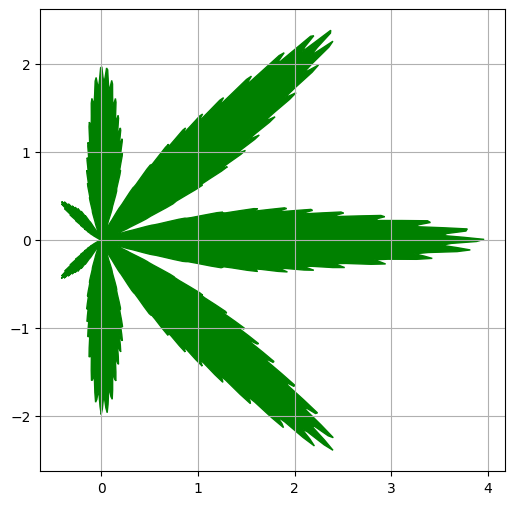

In [3]:
theta = torch.linspace(-np.pi, np.pi, steps=1000)

# посчитайте ро по формуле
rho = (1 + 0.9 * torch.cos(8*theta)) * (1 + 0.1 * torch.cos(24*theta)) * (0.9 + 0.05 * torch.cos(200*theta)) * (1 + torch.sin(theta))
print(rho.shape)

# Преобразуйте пары (ро, тета) в пары (x, y)
x = rho * torch.sin(theta)
y = rho * torch.cos(theta)

plt.figure(figsize=[6, 6])
plt.fill(x.numpy(), y.numpy(), color='green')
plt.grid()

## Задание 1.2 (2 pt)

Научиться гибко управлять формой тензоров без копирования данных — критически важный навык при работе с свёртками и другими сетями. Без приувеличения, несовпадение размерностей — самая важная проблема при первых попытках работы с нейронными сетями. Поэтому крайне важно понимать, как можно **менять размерности** без лишних телодвижений.

**Теория в двух словах:**

|Метод|Что делает|Когда использовать|
|:----|:---------|:-----------------|
| `.view()` / `.reshape()` | Меняет форму без копирования (если возможно) | «Вытягивание» изображения в вектор |
| `.unsqueeze(dim)` | Добавляет размерность 1 по указанной оси | Подготовка данных для свёртки (batch, channels, H, W) |
| `.squeeze()` | Убирает размерности 1 | После операций, добавляющих лишние оси |
| `.permute(*dims)` | Меняет порядок осей | Конвертация между форматами (например, NHWC → NCHW) |

В реальных задачах часто приходится комбинировать тензоры разных размерностей:

* Батч изображений [B, C, H, W] с весами свёртки [out, in, kH, kW]
* Эмбеддинги токенов [B, T, D] с матрицей внимания [B, T, T]
* Выходы рекуррентной сети [T, B, H] с линейным слоем [H, V]

Умение управлять размерностями через `unsqueeze`, `squeeze`, `reshape` и `matmul` — ключевой навык для эффективной работы с нейросетями. Ассерты помогают отлавливать ошибки на ранних этапах разработки.

**Задание:**  

У вас есть батч чёрно-белых изображений букв из датасета NotMNIST:
* Исходный формат: [32, 28, 28] — 32 изображения размером 28×28 пикселей
* Вам нужно подготовить данные для трёх разных архитектур:
> - Свёрточная сеть (CNN) - [32, 1, 28, 28] - Ось канала обязательна даже для ч/б изображений
> - Полносвязная сеть (MLP) - [32, 784] - Изображение "вытягивается" в вектор признаков
> - Рекуррентная сеть (RNN) - [28, 32, 28] - Формат [время, батч, признаки] для обработки строк пикселей

Реализуйте функцию `prepare_for_architectures`

In [4]:
def prepare_for_architectures(images):
    assert images.shape == (32, 28, 28)

    cnn_ready = images.unsqueeze(1) # используйте .unsqueeze()

    mlp_ready = images.reshape((32, 784))  # используйте .reshape() или .view()

    rnn_ready = images.permute(1, 0, 2)  # используйте .permute()

    return cnn_ready, mlp_ready, rnn_ready

In [5]:
images = torch.randn(32, 28, 28)

cnn_ready, mlp_ready, rnn_ready = prepare_for_architectures(images)

assert cnn_ready.shape == (32, 1, 28, 28), f"Ошибка в cnn_ready: {cnn_ready.shape}"
assert mlp_ready.shape == (32, 784), f"Ошибка в mlp_ready: {mlp_ready.shape}"
assert rnn_ready.shape == (28, 32, 28), f"Ошибка в rnn_ready: {rnn_ready.shape}"

## Задание 1.3 (2 pt)

Теперь пора придумать что-то более сложное. Мы реализуем [Game of Life](https://web.stanford.edu/class/sts129/Alife/html/Life.htm) в чистом виде на PyTorch.

Хотя это все еще игрушечная задача, реализация "игры жизни" таким способом имеет одно важное преимущество: вы сможете запускать ее на **GPU**! Советую использовать Google Colab, если у вас нет своей gpu.

**Правила такие:**

* У вас есть двумерная сетка ячеек, где каждая ячейка является "живой" (1) или "мертвой"(0)  
* Любая живая клетка, у которой есть 2 или 3 соседа, выживает, в противном случае она умирает (0,1 или более 4 соседей)  
* Любая ячейка, у которой ровно 3 соседа, становится живой (если она была мертвой)

Для этой задачи вам предоставляется эталонная реализация NumPy, которую вы должны преобразовать в PyTorch. Код NumPy, основанный на: https://github.com/rougier/numpy-100

Примечание: Вы можете найти свертку в файле `torch.nn.functional.conv2d(Z,filters)`. Обратите внимание, что он имеет другой формат ввода.

Примечание 2: С математической точки зрения, свертка PyTorch на самом деле является взаимной корреляцией. Эти две операции очень похожи. Дополнительная информация: [video tutorial](https://www.youtube.com/watch?v=C3EEy8adxvc), [scipy functions review](https://stackoverflow.com/questions/16121269/2d-convolution-in-python-similar-to-matlabs-conv2), [stack overflow source](https://stackoverflow.com/questions/31139977/comparing-matlabs-conv2-with-scipys-convolve2d).

In [6]:
from scipy.signal import correlate2d

# Референсная реализация на NumPy (для проверки)
def np_update(Z):
    # Count neighbours with convolution
    filters = np.array([[1, 1, 1],
                        [1, 0, 1],
                        [1, 1, 1]])

    N = correlate2d(Z, filters, mode='same')

    # Apply rules
    birth = (N == 3) & (Z == 0)
    survive = ((N == 2) | (N == 3)) & (Z == 1)

    Z[:] = birth | survive
    return Z

In [7]:
def torch_update(Z):
    """
    Implement an update function that does to Z exactly the same as np_update.
    :param Z: torch.FloatTensor of shape [height,width] containing 0s(dead) an 1s(alive)
    :returns: torch.FloatTensor Z after updates.

    You can opt to create new tensor or change Z inplace.
    """

    filters = torch.tensor([[1, 1, 1],
                            [1, 0, 1],
                            [1, 1, 1]], dtype = torch.float32)

    Z_4D = Z.unsqueeze(0).unsqueeze(0)  # Как я понял, тут мы добавляем 2 размерности (батч (он у нас 1, так как один объект (одна матрица)) и канал(у нас он один, так как не цветной))
    filters_4D = filters.unsqueeze(0).unsqueeze(0)  # Как я понял, тут мы добавляем 2 размерности (батч (он у нас 1, так как один объект (одна матрица)) и канал(у нас он один, так как не цветной))

    N_4D = torch.nn.functional.conv2d(Z_4D, filters_4D, padding = 1)

    N = N_4D.squeeze(0).squeeze(0)
    print(N.shape)

    birth = (N == 3) & (Z == 0)
    survive = ((N == 2) | (N == 3)) & (Z == 1)


    Z[:] = birth | survive

    return Z

In [8]:
# initial frame
Z_numpy = np.random.choice([0, 1], p=(0.5, 0.5), size=(100, 100))
Z = torch.from_numpy(Z_numpy).type(torch.FloatTensor)

# your debug polygon :)
Z_new = torch_update(Z.clone())
print(Z.shape)

# tests
Z_reference = np_update(Z_numpy.copy())
assert np.all(Z_new.numpy() == Z_reference), \
    "your PyTorch implementation doesn't match np_update. Look into Z and np_update(ZZ) to investigate."
print("Well done!")

torch.Size([100, 100])
torch.Size([100, 100])
Well done!


Теперь попробуем это визуализировать

torch.Size([100, 100])
torch.Size([100, 100])
torch.Size([100, 100])
torch.Size([100, 100])
torch.Size([100, 100])
torch.Size([100, 100])
torch.Size([100, 100])
torch.Size([100, 100])
torch.Size([100, 100])
torch.Size([100, 100])


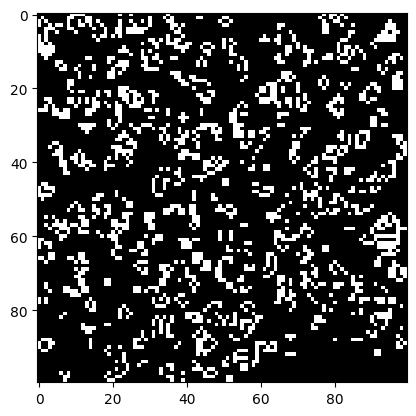

In [9]:
%matplotlib inline
plt.ion()

# initialize game field
Z = np.random.choice([0, 1], size=(100, 100))
Z = torch.from_numpy(Z).type(torch.FloatTensor)

fig = plt.figure()
ax = fig.add_subplot(111)
fig.show()

for _ in range(10):
    # update
    Z = torch_update(Z)

    # re-draw image
    ax.clear()
    ax.imshow(Z.numpy(), cmap='gray')
    fig.canvas.draw()

torch.Size([100, 100])
torch.Size([100, 100])
torch.Size([100, 100])
torch.Size([100, 100])
torch.Size([100, 100])
torch.Size([100, 100])
torch.Size([100, 100])
torch.Size([100, 100])
torch.Size([100, 100])
torch.Size([100, 100])


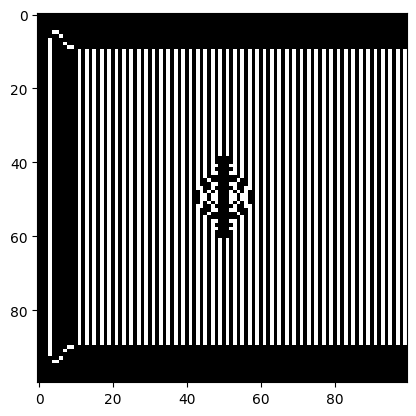

In [10]:
# parallel stripes
Z = np.arange(100) % 2 + np.zeros([100, 100])
# with a small imperfection
Z[48:52, 50] = 1

Z = torch.from_numpy(Z).type(torch.FloatTensor)

fig = plt.figure()
ax = fig.add_subplot(111)
fig.show()

for _ in range(10):
    Z = torch_update(Z)
    ax.clear()
    ax.imshow(Z.numpy(), cmap='gray')
    fig.canvas.draw()

# Часть 2: Полный пайплайн обучения (5 pt)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn
import torch.nn.functional as F

In [12]:
import torch
import numpy as np

def set_seed(random_seed: int = 42):
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(random_seed)

## Задание 2.1 (1 pt)

**Загрузка и подготовка данных NotMNIST**  
Что такое NotMNIST? Это датасет из 10 букв (A–J), похожий на MNIST, но сложнее из-за вариативности шрифтов.  

> _Для скачивания вам нужен файл `notmnist.py`._  
> _Также вам может понадобиться (советую этот вариант) файл `notMNIST_small.tar.gz`. Нужно скачать его и извлечь файлы_  
> _Если что-то ломается, то всегда можно открыть скрипт и скопировать от туда код_

In [13]:
from notmnist import load_notmnist
X_train, y_train, X_test, y_test = load_notmnist(letters='ABCDEFGHIJ')
X_train, X_test = X_train.reshape([-1, 784]), X_test.reshape([-1, 784])

Parsing...
found broken img: ./notMNIST_small/A/RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png [it's ok if <10 images are broken]
found broken img: ./notMNIST_small/F/Q3Jvc3NvdmVyIEJvbGRPYmxpcXVlLnR0Zg==.png [it's ok if <10 images are broken]
Done


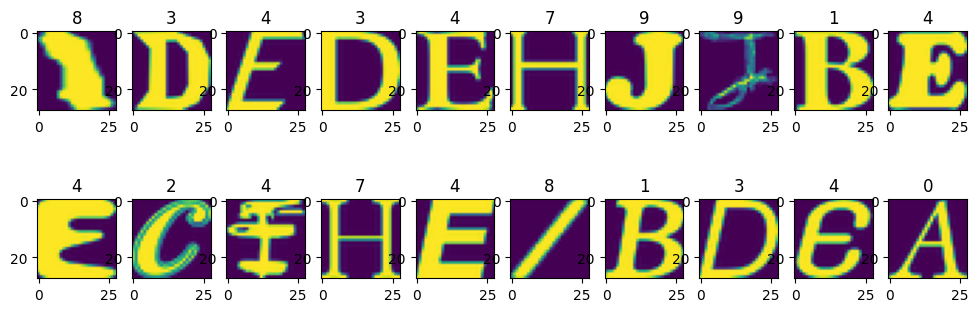

In [14]:
%matplotlib inline
plt.figure(figsize=[12, 4])
for i in range(20):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_train[i].reshape([28, 28]))
    plt.title(str(y_train[i]))

**Задание:**  
Создайте кастомный Dataset и DataLoader

In [15]:
from torch.utils.data import Dataset, DataLoader

set_seed()
BATCH_SIZE = 512

'''
Your dataset item contains image and label (order matters — see train loop!)
'''

class NotMNISTDataset(Dataset):
    def __init__(self, images, labels):
        assert len(images) == len(labels)
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # ВАЖНО: изображение должно быть torch.FloatTensor, метка — torch.LongTensor
        image = torch.tensor(self.images[idx]).float()
        label = torch.tensor(self.labels[idx]).long()
        return image, label

train_not_mnist_dataset = NotMNISTDataset(images=X_train, labels=y_train)
train_not_mnist_dataloader = DataLoader(
    train_not_mnist_dataset,
    batch_size=BATCH_SIZE,
)

test_not_mnist_dataset = NotMNISTDataset(images=X_test, labels=y_test)
test_not_mnist_dataloader = DataLoader(
    test_not_mnist_dataset,
    batch_size=BATCH_SIZE,
)

## Задание 2.2 (1 pt)

**Архитектура**  

Будем для простоты использовать обычные полносвязные слои и простые функции активации.

**Задание:** дополните архитектуру сети

Важно! Для задачи классификации с 10 классами:

* На выходе используем `log_softmax` (а не обычный `softmax`)  
* Функция потерь — `F.nll_loss` (Negative Log Likelihood). Это численно стабильнее, чем `softmax` + `cross_entropy`  

In [16]:
class SimpleModel(nn.Module):
    def __init__(self, hidden_dim: int = 100):
        super().__init__()
        self.linear_1 = nn.Linear(in_features = 28*28, out_features = hidden_dim, bias = True)
        self.linear_2 = nn.Linear(in_features = hidden_dim, out_features = 10, bias = True)

    def forward(self, images):
        data = self.linear_1(images)
        data = torch.relu(data)

        data = self.linear_2(data)
        predicted = torch.log_softmax(data, dim=1)
        return predicted

## Задание 2.3 (1 pt)

**Обучающий цикл**  

В этом задании вам нужно дополнить цикл обучения так, чтобы сохранять историю метрик и лосса.  

Написание обучающего цикла очень важная, но довольно шаблонная часть. Обратите внимание на **оптимайзер** и на то, что все вычисления нужно проводить на **одном устройстве** (gpu/cpu)!

**Задание:** дописать обучающий цикл и обучить модель

In [17]:
def calc_loss(model, images, labels):
    predicts = model(images)
    loss_value = F.nll_loss(predicts, labels)
    return loss_value

def calc_batch_avg_accuracy(predicts, labels, batch_size):
    return (predicts.argmax(dim=1) == labels).sum() / batch_size

In [18]:
import torch.nn.functional as F
from tqdm.auto import tqdm

set_seed()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

model = SimpleModel()
model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

accs = []
train_losses = []
n_epochs = 100

for epoch in tqdm(range(n_epochs)):
    avg_loss = 0

    for batch in train_not_mnist_dataloader:
        images, labels = batch
        images = images.to(device) # to GPU or CPU
        labels = labels.to(device)

        loss_value = calc_loss(model, images, labels)

        optimizer.zero_grad() # !!!
        loss_value.backward() # !!!
        optimizer.step() # !!!

        avg_loss += loss_value

    train_losses.append(avg_loss / len(test_not_mnist_dataloader))

    avg_acc = 0

    for batch in test_not_mnist_dataloader:
        images, labels = batch
        images = images.to(device)
        labels = labels.to(device)

        predicts = model(images)

        accuracy = calc_batch_avg_accuracy(predicts, labels, BATCH_SIZE)
        avg_acc += accuracy

    avg_acc /= len(test_not_mnist_dataloader)
    accs.append(avg_acc)

cpu


  0%|          | 0/100 [00:00<?, ?it/s]

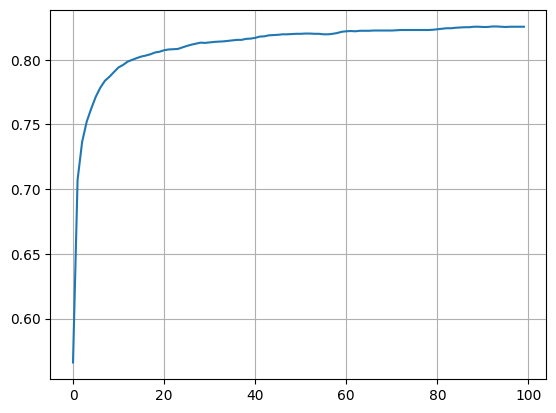

In [19]:
accs = [acc.cpu() for acc in accs]
plt.grid()
plt.plot(np.arange(0, n_epochs), accs)

/tmp/ipykernel_1707/3472845884.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.plot(np.arange(0, n_epochs), [float(tl) for tl in train_losses])


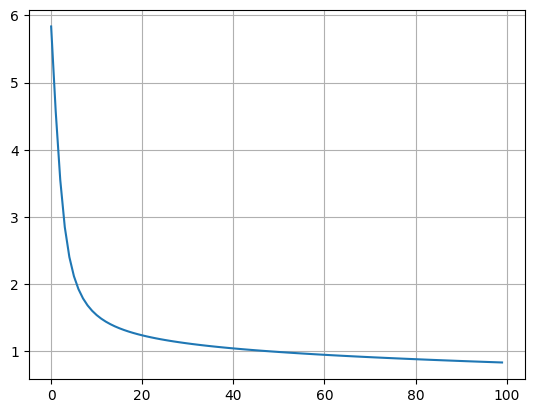

In [20]:
plt.grid()
plt.plot(np.arange(0, n_epochs), [float(tl) for tl in train_losses])

## Задание 2.4 (2 pt)

Это задание остается для вас творческим. Вам необходимо проанализировать как минимум то, какие буквы модель путает чаще всего. Реализуйте ваше исследование любым удобным вам способом.

**Задание:** напишите небольшой отчет о части 2 (пайплайне обучения): какие самые важные моменты вы выделяете, насколько хорошие получились метрики, проведите анализ ошибок модели.

### Графики точности и ошибок модели на каждой из букв датасета.

In [21]:
class BatchResult:
  def __init__(self):
      self.acc_sum= 0
      self.loss_sum = 0
      self.quantity = 0

  def add(self, acc, loss):
      self.acc_sum += acc
      self.loss_sum += loss
      self.quantity += 1

  def get_average(self):
      return self.avg_acc, self.avg_loss

  def print_average(self):
      print(f'Avg Accuracy: {self.avg_acc} | Avg Loss: {self.avg_loss}')

  @property
  def avg_acc(self):
      return self.acc_sum / self.quantity

  @property
  def avg_loss(self):
      return self.loss_sum / self.quantity


class LetterResult:
    def __init__(self, avg_acc = 0, avg_loss = 0):
        self.avg_acc = avg_acc
        self.avg_loss = avg_loss

    def load_from_br(self, br: BatchResult):
        self.avg_acc, self.avg_loss = br.get_average()

def plot_bar(diagram_name: str, categories_names: list[str], values: list[str], x_name = '', y_name = ''):
    bar = plt.bar(categories_names, values)
    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.title(diagram_name)
    plt.show()

def plot_bar_letters(letters_results: dict[str, LetterResult], param: str):
    cat_names = letters_results.keys()
    if param == 'accuracy':
        values = [lr.avg_acc.detach().numpy() for lr in letters_results.values()]
    elif param == 'loss':
        values = [lr.avg_loss.detach().numpy() for lr in letters_results.values()]
    else:
      raise ValueError('Parameter not found')

    plot_bar(param[0].upper() + param[1:] + ' of Letters', cat_names, values, 'letter', param)

P.S.

Оказывается, load_notmnist создает каждый раз заного ключи под те буквы, которые передали в аргумент letters. Т.е. если мы передадим 'ABCD' - получим keys = [0, 1, 2, 3]. Если передадим 'DEFJ' - тоже получим [0, 1, 2, 3], а не [3, 4, 5, 6]. Поэтому когда я загружаю датасет только для одной буквы у меня каждый раз нумерация ключей с нуля начинается... Я потратил на то, чтобы это найти, несколько часов...

In [22]:
all_letters = 'ABCDEFGHIJ'
results = dict[str, LetterResult]()

for letter in all_letters:

    print(f'Letter {letter}')
    lr = LetterResult()
    X_letter, y_letter, _, _ = load_notmnist(letters=letter, test_size = 0.001)
    X_letter = X_letter.reshape([-1, 784])
    y_letter += int(letter, 20) - int('A', 20)

    print(f'Size {len(X_letter)}')
    valletter_not_mnist_dataset = NotMNISTDataset(images=X_letter, labels=y_letter)
    valletter_not_mnist_dataloader = DataLoader(
        valletter_not_mnist_dataset,
        batch_size=BATCH_SIZE,
    )

    br = BatchResult()
    for batch in valletter_not_mnist_dataloader:
        imgs, labels = batch
        imgs = imgs.to(device)
        labels = labels.to(device)

        predicts = model(imgs)

        acc = calc_batch_avg_accuracy(predicts, labels, len(labels))
        loss_value = F.nll_loss(predicts, labels)
        br.add(acc, loss_value)

    br.print_average()
    lr.load_from_br(br)
    results[letter] = lr

Letter A
Parsing...
found broken img: ./notMNIST_small/A/RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png [it's ok if <10 images are broken]
Done
Size 1870
Avg Accuracy: 0.9215211868286133 | Avg Loss: 0.24630363285541534
Letter B
Parsing...
Done
Size 1871
Avg Accuracy: 0.896188497543335 | Avg Loss: 0.3350292444229126
Letter C
Parsing...
Done
Size 1871
Avg Accuracy: 0.9257069230079651 | Avg Loss: 0.28082817792892456
Letter D
Parsing...
Done
Size 1871
Avg Accuracy: 0.9306174516677856 | Avg Loss: 0.2587014436721802
Letter E
Parsing...
Done
Size 1871
Avg Accuracy: 0.8857319951057434 | Avg Loss: 0.3681216239929199
Letter F
Parsing...
found broken img: ./notMNIST_small/F/Q3Jvc3NvdmVyIEJvbGRPYmxpcXVlLnR0Zg==.png [it's ok if <10 images are broken]
Done
Size 1870
Avg Accuracy: 0.936529278755188 | Avg Loss: 0.2734375
Letter G
Parsing...
Done
Size 1870
Avg Accuracy: 0.9006917476654053 | Avg Loss: 0.33303019404411316
Letter H
Parsing...
Done
Size 1870
Avg Accuracy: 0.903489887714386 | Avg Loss: 0.

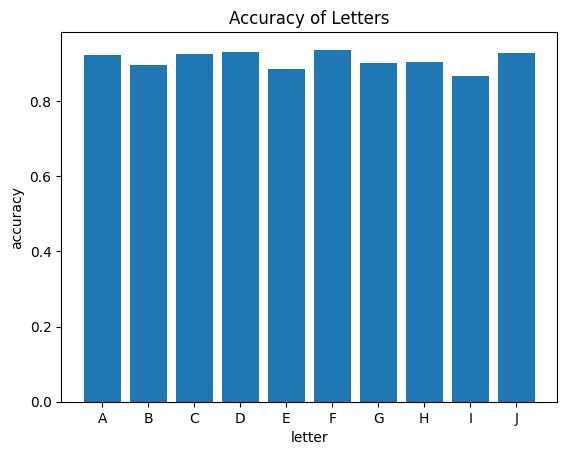

In [23]:
plot_bar_letters(results, 'accuracy')

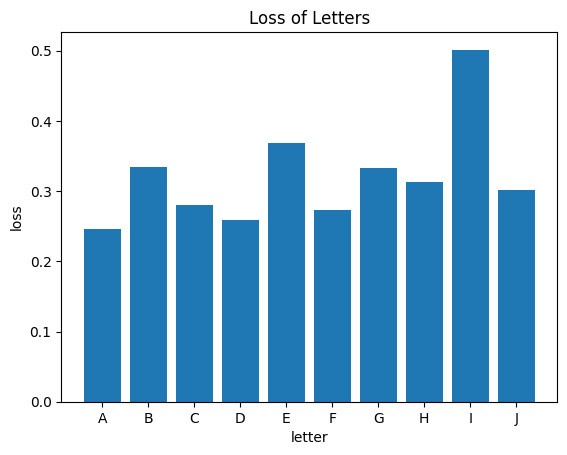

In [24]:
plot_bar_letters(results, 'loss')

Получается, что чаще всего модель ошибается на буквах I.

Есть гипотеза, что модель путает I с J, так как они визуально похожи. Либо в датасете просто мало фотографий с буквой I.

Вторая гипотеза отпадает, так как, согласно выводу моего кода выше, у I около 1870 объектов (фотографий/меток), что не сильно отличается от объемов данных для других букв.

Значит, скорее всего, дело в гипотезе 1:

### Анализ и выводы, почему у I самая низкая точность и большая ошибка

Посмотрим на буквы J:

Parsing...
Done


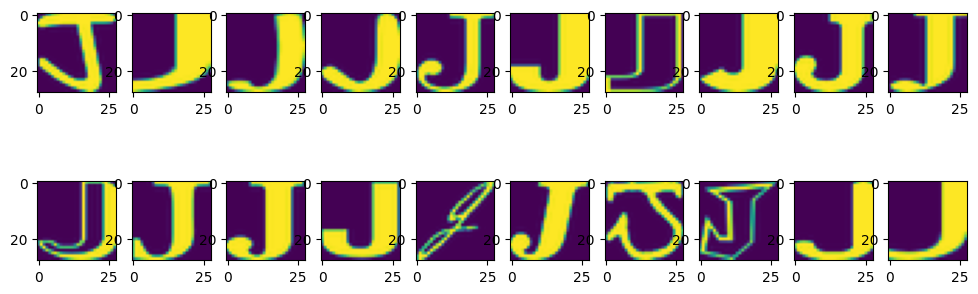

In [25]:
X_J, y_J, _, _ = load_notmnist(letters='J', test_size = 0.001)
plt.figure(figsize=[12, 4])
for i in range(20):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_J[i].reshape([28, 28]))

Теперь посмотрим на буквы I:

Parsing...
Done


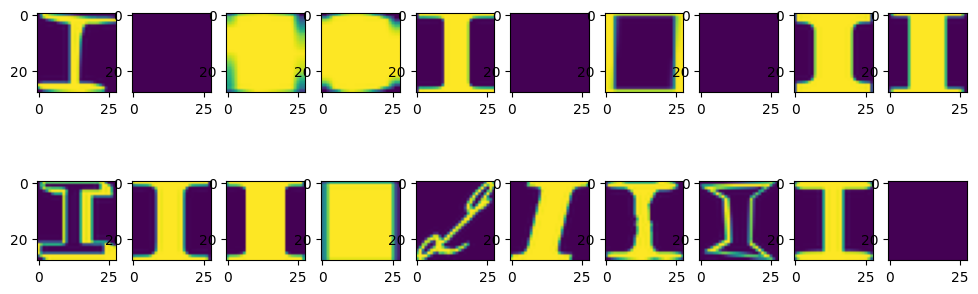

In [26]:
X_I, y_I, _, _ = load_notmnist(letters='I', test_size = 0.001)
plt.figure(figsize=[12, 4])
for i in range(20):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_I[i].reshape([28, 28]))

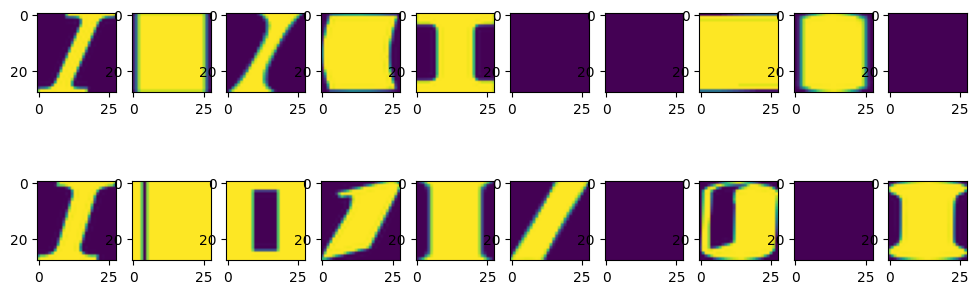

In [27]:
plt.figure(figsize=[12, 4])
for i in range(20, 40):
    plt.subplot(2, 10, i-19)
    plt.imshow(X_I[i].reshape([28, 28]))

Как-будто, просто в датасете шума много. Квадрат (картинка) где-то либо пустой, либо полностью желтый. Где-то другие буквы.

Интересно, можно ли автоматизировать проверку количества "выбросов" в датасете. Давайте найдем количетство "пустых" и "полностью закрашенных" изображений:

In [28]:
# Подсчет яркости изображения в процентах (% от максимальной яркости во всем датасете)
def how_brightness(image: np.ndarray, images_min, images_max) -> float:
    assert (image.mean() - images_min) <= (images_max - images_min), ((image.mean() - images_min), (images_max - images_min))
    return (image.mean() - images_min) / (images_max - images_min)

In [29]:
def calc_percent_of_empty_or_fillin(images, low_threshold = 0.1, up_threshold = 0.9, epsilon = 0.000001):
    images_max = images.max() + epsilon # Иногда из-за округления могут ошибки возникать, поэтому добавляю эпсилон
    images_min = images.min() - epsilon
    brightness_of_images = [how_brightness(img, images_min, images_max) for img in images]
    empty_images = sum([bif >= up_threshold or bif <= low_threshold for bif in brightness_of_images])
    return empty_images / len(brightness_of_images)

In [30]:
calc_percent_of_empty_or_fillin(X_I)

np.float64(0.21122994652406418)

In [31]:
calc_percent_of_empty_or_fillin(X_J)

np.float64(0.019786096256684493)

Итого, 21% фотографий - это мусор, который можно выкинуть.
Еще часть - очень похожа на букву J.
В итоге получаем, что данных маловато, чтобы модель научилась различать I и J нормально.

Для сравнения - в X_J всего 2% таких мусорных изображений.

### Анализ засоренности датасета для каждой из букв

In [32]:
all_letters = 'ABCDEFGHIJ'
emissions_dict = dict[str, float]()

for letter in all_letters:
    X_letter, y_letter, _, _ = load_notmnist(letters=letter, test_size = 0.001)
    emissions_dict[letter] = calc_percent_of_empty_or_fillin(X_letter, 0.1, 0.9)

Parsing...
found broken img: ./notMNIST_small/A/RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png [it's ok if <10 images are broken]
Done
Parsing...
Done
Parsing...
Done
Parsing...
Done
Parsing...
Done
Parsing...
found broken img: ./notMNIST_small/F/Q3Jvc3NvdmVyIEJvbGRPYmxpcXVlLnR0Zg==.png [it's ok if <10 images are broken]
Done
Parsing...
Done
Parsing...
Done
Parsing...
Done
Parsing...
Done


In [33]:
for letter, perc in emissions_dict.items():
    print(f'{letter}: {perc}')

A: 0.0106951871657754
B: 0.005879208979155532
C: 0.011758417958311064
D: 0.009086050240513094
E: 0.0074826296098343134
F: 0.013368983957219251
G: 0.0074866310160427805
H: 0.0106951871657754
I: 0.21122994652406418
J: 0.019786096256684493


По-сути да, причина низкой точности в том, что во-первых датасет для буквы I самый загрязненный датасет из всех.

А во-вторых, I очень похожа на J и, скорее всего, это тоже вносит свой вклад в точность, так как на тесте модель может распознавать такие "партизанские" I как J. Правда, не совсем понятно, как это автоматизированно проверить, а не ручками.

### Общие выводы по части 2

Выводы:
В целом, модель показывает себя достаточно неплохо: точность около 0.9 на каждой из букв. Конечно, стоило бы почистить данные от выбросов. Тогда, возможно, точность бы улучшилась.

P.S. Если что, комментарии к функциям (все, которых не было в исходном файле) я сам писал, НЕ НЕЙРОНКА! Правда =)